# MINTERPY/n-dimensional fitting for PCO FA fragmentation data

## Packages and definitions

Please install required project specific python packages.

pip install minterpy | cvxpy | sympy

In [1]:
# basic python packages
import numpy as np
import pandas as pd

# specific python packages
import minterpy as mp
import cvxpy as cp
# added by Damar for handling equations
import sympy as sp

# visualisation tools
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.widgets  import RectangleSelector
from minterpy.core.utils import get_exponent_matrix
import matplotlib.patches as patches

#others
import minterpy_functions as mf
import pickle

## Import of required data

### Import and conversion of PCO fragmentation data

In [2]:
# import FA anion fragment data via csv
df = pd.read_csv(r"./frag_data/211004_PCO_sn2_FA.csv")

# subsetting of relevant data
cols = ['CE', 'FA_C_y', 'FA_DB_y', 'FA_iso_y']

# analyte information to_numpy()
sample_points = df[cols].to_numpy()
function_vals = df['norm_Intensity'].to_numpy()

### Get overview used analytes

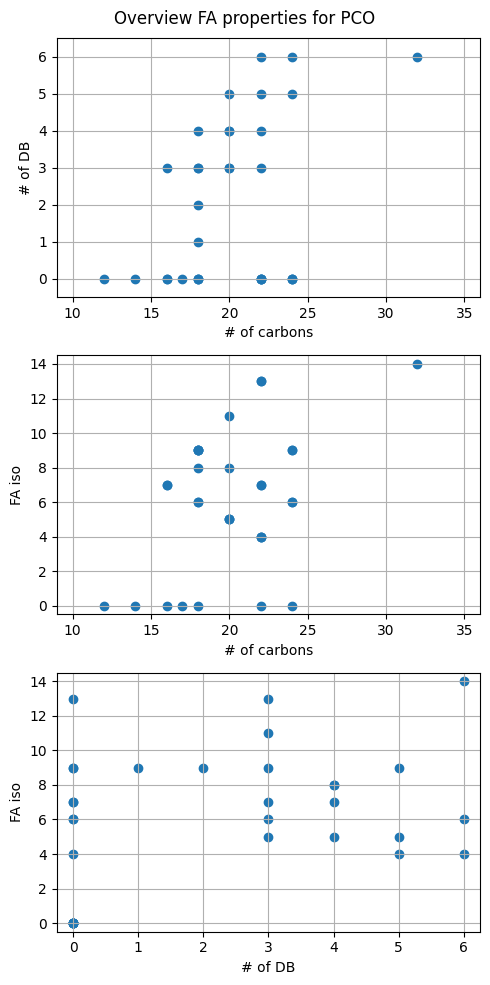

In [3]:
## get dataframe with needed properties
overview_df = df[['FA_C_y', 'FA_DB_y', 'FA_iso_y']].drop_duplicates()

fig, ax = plt.subplots(3,1, figsize=(5,10))

fig.suptitle('Overview FA properties for PCO')

# plot number of carbons vs number of DB
ax = plt.subplot(3,1,1)
plt.scatter(overview_df.FA_C_y, overview_df.FA_DB_y)
ax.set_xlim(9,36)
ax.set_ylim(-0.5,6.5)
ax.set_xlabel('# of carbons')
ax.set_ylabel('# of DB')
ax.grid(which='both')

# plot number of carbons vs DB position
ax = plt.subplot(3,1,2)
plt.scatter(overview_df.FA_C_y, overview_df.FA_iso_y)
ax.set_xlim(9,36)
ax.set_ylim(-0.5,14.5)
ax.set_xlabel('# of carbons')
ax.set_ylabel('FA iso')
ax.grid(which='both')

# plot number of DB vs DB position
ax = plt.subplot(3,1,3)
plt.scatter(overview_df.FA_DB_y, overview_df.FA_iso_y)
ax.set_xlim(-0.25,6.25)
ax.set_ylim(-0.5,14.5)
ax.set_xlabel('# of DB')
ax.set_ylabel('FA iso')
ax.grid(which='both')

plt.tight_layout()
plt.show()

In [4]:
a_uni = np.array(overview_df.sort_values(by=['FA_C_y', 'FA_DB_y', 'FA_iso_y']))
a_uni

array([[12,  0,  0],
       [14,  0,  0],
       [16,  0,  0],
       [16,  0,  7],
       [16,  3,  7],
       [17,  0,  0],
       [18,  0,  0],
       [18,  0,  6],
       [18,  0,  9],
       [18,  1,  9],
       [18,  2,  9],
       [18,  3,  6],
       [18,  3,  9],
       [18,  4,  8],
       [20,  3,  5],
       [20,  3, 11],
       [20,  4,  5],
       [20,  4,  8],
       [20,  5,  5],
       [22,  0,  0],
       [22,  0,  4],
       [22,  0,  7],
       [22,  0, 13],
       [22,  3, 13],
       [22,  4,  7],
       [22,  5,  4],
       [22,  6,  4],
       [24,  0,  0],
       [24,  0,  6],
       [24,  0,  9],
       [24,  5,  9],
       [24,  6,  6],
       [32,  6, 14]], dtype=int64)

## MINTERPY/n-dimensional fitting of PCO FA fragment data

In [5]:
sparse_poly_model = mf.lasso_fit_data(
    sample_points,
    function_vals,
    poly_degree_along=[8,2,2,2],
    weighted=True,
)

c:\Users\schuhmann\AppData\Local\Programs\Python\Python312\Lib\site-packages\minterpy\schemes\barycentric\operators.py:47: UserWarning: building a full transformation matrix from a barycentric transformation. this is inefficient.
  warn(


Optimizer result : 316.8068394436509


### Check of fit quality

L_inf error of fitting SYM dataset = 40.6123335970832


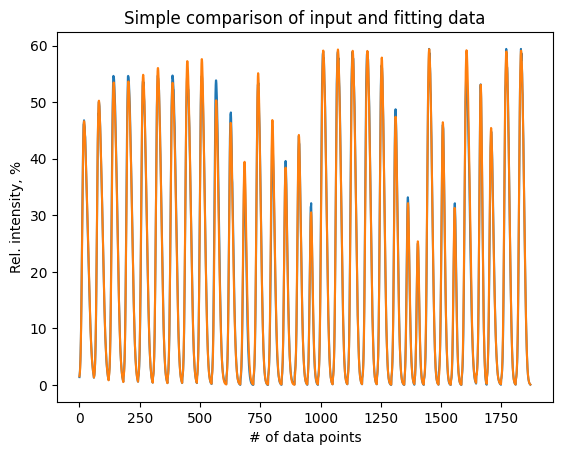

In [6]:
lower_bounds = np.round(np.amin(sample_points, axis=0))
upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

eval_vals = mf.poly_evaluate_at(sparse_poly_model, sample_points, lower_bounds, upper_bounds)

abs_errs = pow(2,eval_vals) - function_vals
rel_errs = np.divide(abs_errs, function_vals)
Linf_error = np.max(np.abs(rel_errs))
print(f"L_inf error of fitting SYM dataset = {Linf_error}")

plt.title("Simple comparison of input and fitting data")
plt.plot(function_vals)
plt.plot(pow(2,eval_vals))
plt.xlabel("# of data points")
plt.ylabel("Rel. intensity, %")
plt.show()

## Visualization of fitting data/results

### Fragment intensity contour plot for saturated FA

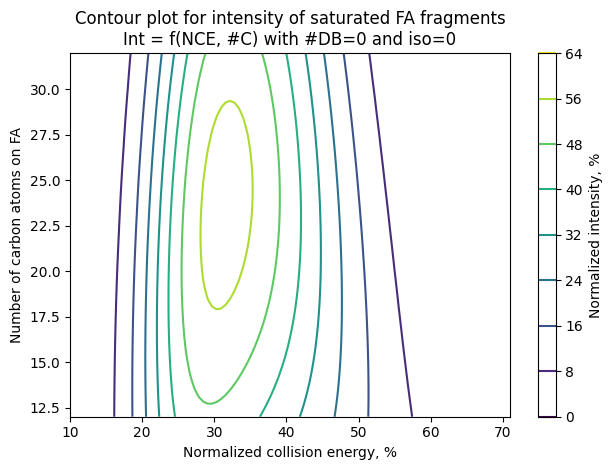

In [7]:
lower_bounds = np.round(np.amin(sample_points, axis=0))
upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 12 #lower_bounds[1]
yhi = 32 #upper_bounds[1]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_db = 0
fa_iso = 0

num_points_in_grid = len(coords_y)
eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x ## NCE
eval_points[:,1] = coords_y ## FA_C
eval_points[:,2] = fa_db
eval_points[:,3] = fa_iso

eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of saturated FA fragments\nInt = f(NCE, #C) with #DB=0 and iso=0")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of carbon atoms on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar().set_label('Normalized intensity, %')

plt.tight_layout()
plt.show()

In [8]:
# # optional visualization
# lower_bounds = np.round(np.amin(sample_points, axis=0))
# upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

# xlo = lower_bounds[0]
# xhi = upper_bounds[0]
# ylo = 12 #lower_bounds[1]
# yhi = 32 #upper_bounds[1]

# xvals = np.linspace(xlo, xhi, 100)
# yvals = np.linspace(ylo, yhi, 100)

# # yvals

# X,Y = np.meshgrid(xvals, yvals)
# coords_x = X.reshape(-1)
# coords_y = Y.reshape(-1)

# fa_db = 0
# fa_iso = 0

# num_points_in_grid = len(coords_y)
# eval_points = np.zeros((num_points_in_grid, 4))
# eval_points[:,0] = coords_x ## NCE
# eval_points[:,1] = coords_y ## FA_C
# eval_points[:,2] = fa_db
# eval_points[:,3] = fa_iso


# eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)

# # Reshape eval_vals to match the grid dimensions
# Z = pow(2,eval_vals.reshape((100,100)))
# Z_masked = np.ma.masked_array(Z, Z < 0)

# # Create a heatmap (2D plot)
# plt.imshow(Z_masked, origin='lower', extent=[xlo, xhi, ylo, yhi], aspect='auto', cmap='viridis')
# plt.colorbar(label='Relative intensity, %')
# plt.xlabel('Normalized collision energy, %')
# plt.ylabel('Number of carbon atoms')

# # Contour lines (optional)
# contour_levels = np.linspace(np.min(Z), np.max(Z), 10)
# plt.contour(X, Y, Z_masked, levels=contour_levels, colors='k', linewidths=0.5)

# plt.tight_layout()
# plt.show()

In [9]:
# # in case 3D is interesting
# # to generate a 3d plot of the contour plot

# # %matplotlib widget

# # from mpl_toolkits.mplot3d import Axes3D


# from scipy.spatial import Delaunay

# # Your existing code

# lower_bounds = np.round(np.amin(sample_points, axis=0))
# upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

# xlo = lower_bounds[0]
# xhi = upper_bounds[0]
# ylo = 12 #lower_bounds[1]
# yhi = 32 #upper_bounds[1]

# xvals = np.linspace(xlo, xhi, 100)
# yvals = np.linspace(ylo, yhi, 100)

# X,Y = np.meshgrid(xvals, yvals)
# coords_x = X.reshape(-1)
# coords_y = Y.reshape(-1)

# fa_db = 0
# fa_iso = 0

# num_points_in_grid = len(coords_y)

# eval_points = np.zeros((num_points_in_grid, 4))
# eval_points[:,0] = coords_x ## NCE
# eval_points[:,1] = coords_y ## FA_C
# eval_points[:,2] = fa_db
# eval_points[:,3] = fa_iso

# eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)

# # Additional code for the 3D plot
# Z = eval_vals.reshape(X.shape)

# # Create a mask for Z values >= 0
# mask = Z >= 0

# fig = plt.figure(dpi=300)
# ax = fig.add_subplot(111, projection='3d')

# # Compute the Delaunay triangulation of the data points
# triang = Delaunay(np.vstack((X[mask], Y[mask])).T)

# # Plot the smooth surface using trisurf
# surf = ax.plot_trisurf(X[mask].ravel(), Y[mask].ravel(), Z[mask].ravel(), triangles=triang.simplices, cmap='viridis', alpha=0.8, linewidth=0)


# ax.set_xlabel('NCE')
# ax.set_ylabel('FA_C')
# ax.set_zlabel('Relative intensity')

# # ax.set_zlim(0)

# # Set view angle using elevation (elev) and azimuthal angle (azim)
# elev = 30  # Degrees of elevation above the xy-plane
# azim = -120  # Degrees of rotation counterclockwise around the z-axis
# ax.view_init(elev, azim)

# plt.show()

### Fragment intensity contour plot for polyunsaturated FA

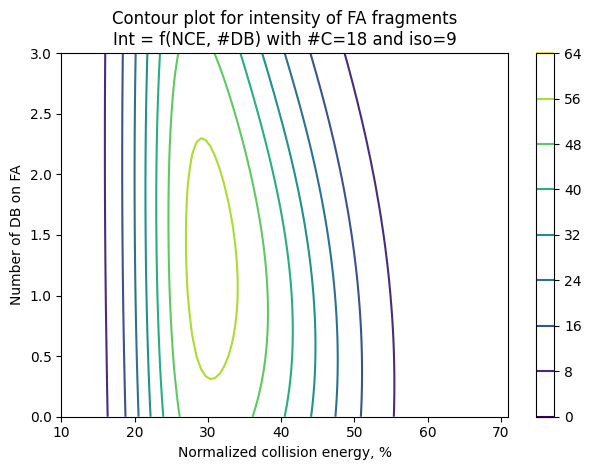

In [10]:
lower_bounds = np.round(np.amin(sample_points, axis=0))
upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 3 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 18
fa_iso = 9

num_points_in_grid = len(coords_y)
eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso

eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of FA fragments\nInt = f(NCE, #DB) with #C=18 and iso=9")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of DB on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar()

plt.tight_layout()
plt.show()

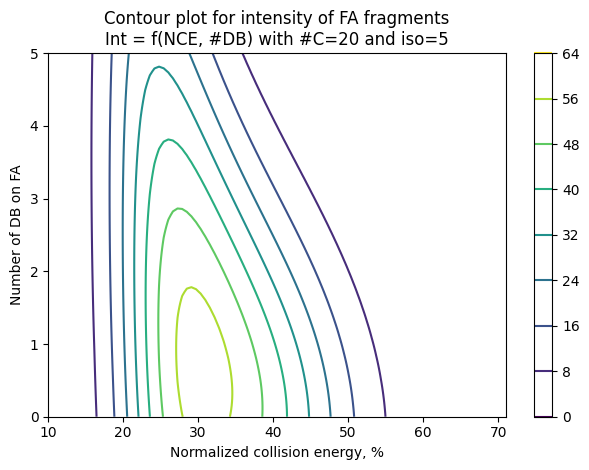

In [11]:
lower_bounds = np.round(np.amin(sample_points, axis=0))
upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 5 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 20
fa_iso = 5

num_points_in_grid = len(coords_y)
eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso

eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of FA fragments\nInt = f(NCE, #DB) with #C=20 and iso=5")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of DB on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar()

plt.tight_layout()
plt.show()

### Comparison of fragment intensities : measured vs calculated via MINTERPY/ndim fitting

#### Comparison for saturated FA

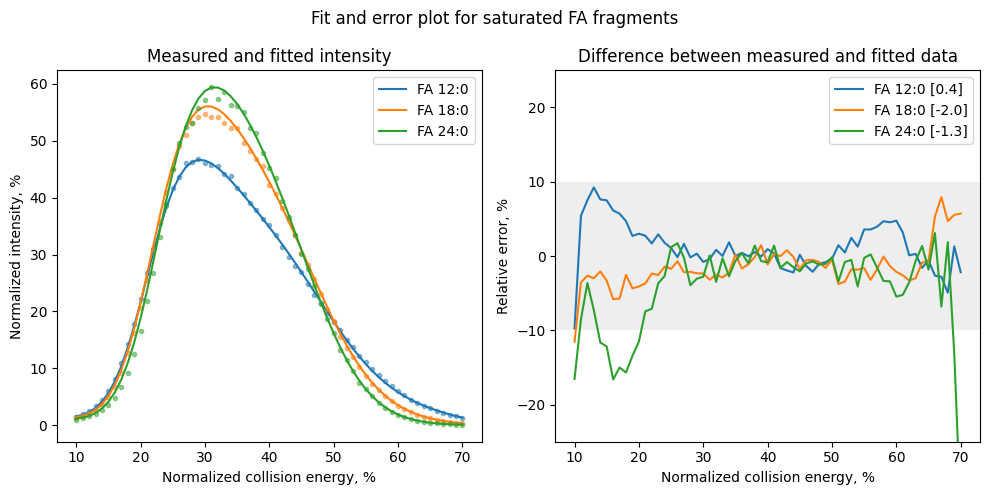

In [12]:
# color definition for plots
colors = [('tab:blue', '#1f77b4'), ('tab:orange', '#ff7f0e'), ('tab:green', '#2ca02c'), ('tab:red', '#d62728'), ('tab:purple', '#9467bd'), ('tab:brown', '#8c564b'), ('tab:pink', '#e377c2'), ('tab:gray', '#7f7f7f'), ('tab:olive', '#bcbd22'), ('tab:cyan', '#17becf')]

nce = [10,70] # range of nce
FA_oi = [[12, 0, 0], [18, 0, 0], [24, 0, 0]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle("Fit and error plot for saturated FA fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C_y == C) & (df.FA_DB_y == DB) & (df.FA_iso_y == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])


# axes label     
ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Comparison for FAs with 18 carbons and different DBs

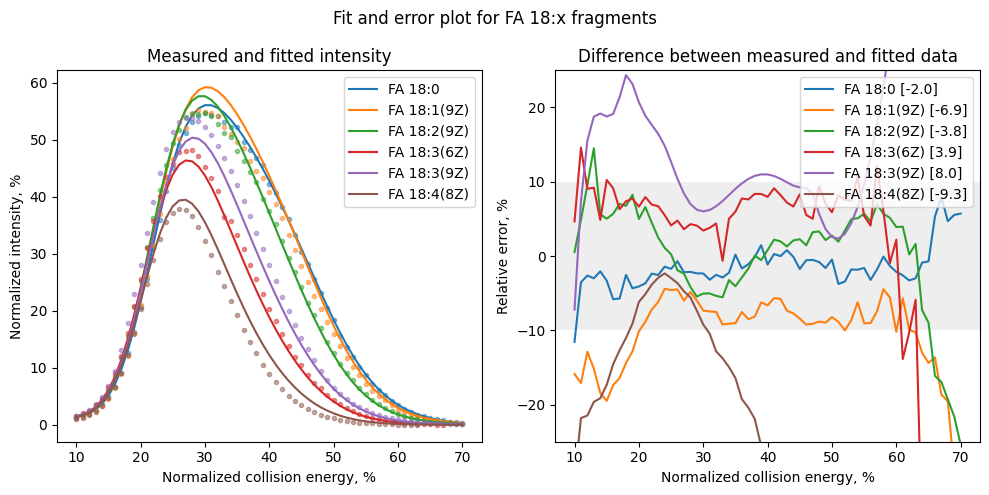

In [13]:
nce = [10,70] # range of nce
FA_oi = [[18, 0, 0], [18, 1, 9], [18, 2, 9], [18, 3, 6], [18, 3, 9], [18, 4, 8]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA 18:x fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C_y == C) & (df.FA_DB_y == DB) & (df.FA_iso_y == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Comparison for FAs with 20 carbons and different DBs

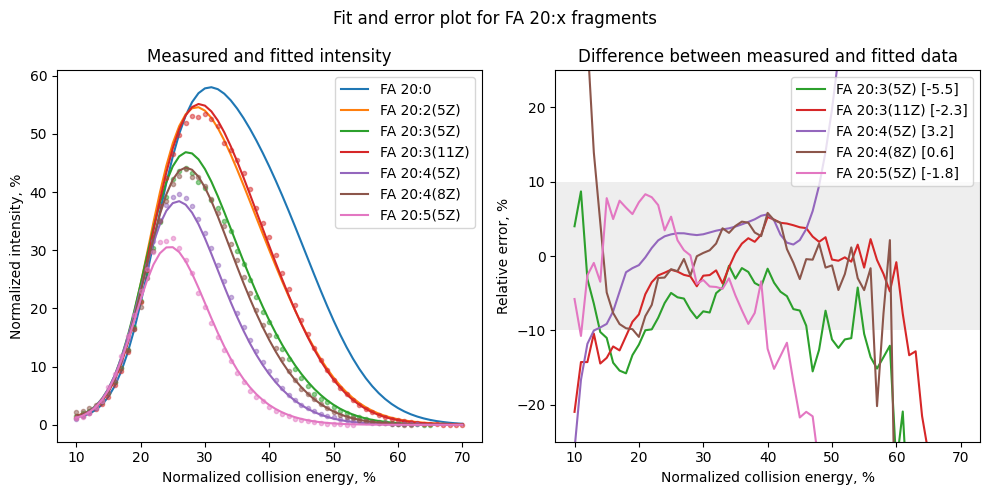

In [14]:
nce = [10,70] # range of nce
FA_oi = [[20, 0, 0], [20, 2, 5], [20, 3, 5], [20, 3, 11], [20, 4, 5], [20, 4, 8], [20, 5, 5]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA 20:x fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C_y == C) & (df.FA_DB_y == DB) & (df.FA_iso_y == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Comparison for FAs with 22 carbons and different DBs

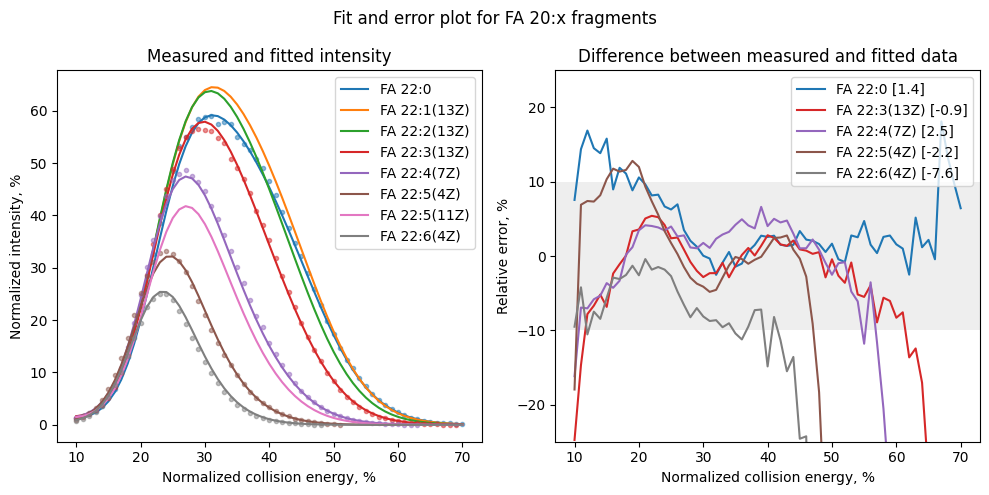

In [15]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 1, 13], [22, 2, 13], [22, 3, 13], [22, 4, 7], [22, 5, 4], [22, 5, 11], [22, 6, 4]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA 20:x fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C_y == C) & (df.FA_DB_y == DB) & (df.FA_iso_y == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Comparison for FAs with 22-32 carbons and 6 DBs

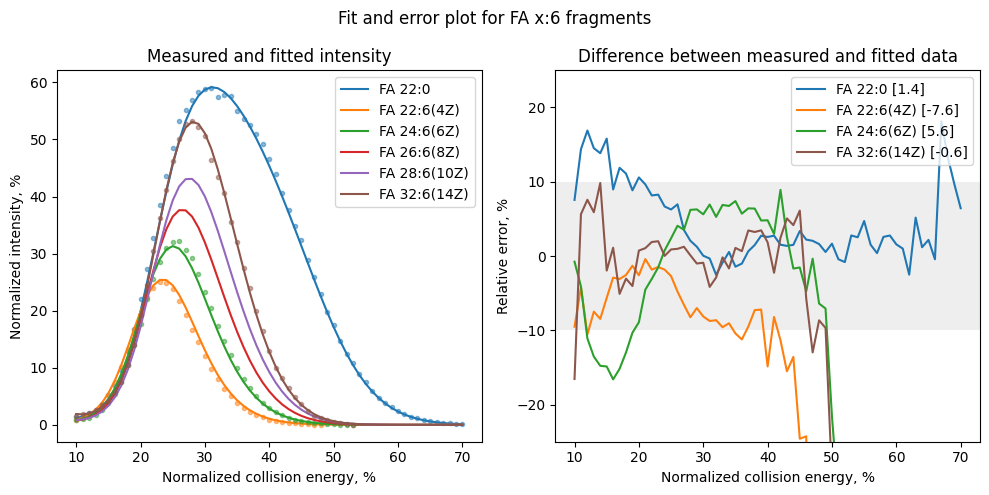

In [16]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 6, 4], [24, 6, 6], [26, 6, 8], [28, 6, 10], [32, 6, 14]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA x:6 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C_y == C) & (df.FA_DB_y == DB) & (df.FA_iso_y == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Handling MINTERPYs ndim equations

### Convertion of NewtonPolynomials for 'equation' 

In [17]:
# Transformation of NewtonPolynomials to Canonical Form
model_can = mp.get_transformation(sparse_poly_model, mp.CanonicalPolynomial)()

trimmed_coeffs = model_can.coeffs.copy()

# conditional coefficient modification, if needed
# trimmed_coeffs[np.where((trimmed_coeffs<1e0) & (trimmed_coeffs>-1e0))] = 0.0
# trimmed_coeffs = np.around(trimmed_coeffs, 2)

model_can.coeffs = trimmed_coeffs
model_eqn = mf.mp_to_sympy(model_can)

# conversion to equation
model_eqn

Poly(3.34895662503947*x_0**8 - 1.2245820232394e-11*x_0**7*x_1**2*x_2**2*x_3**2 - 6.27241720729603e-12*x_0**7*x_1**2*x_2**2*x_3 - 2.15300409724627e-11*x_0**7*x_1**2*x_2**2 - 1.61820794277933e-11*x_0**7*x_1**2*x_2*x_3**2 - 2.75306927028375e-13*x_0**7*x_1**2*x_2*x_3 - 1.65038286628883e-11*x_0**7*x_1**2*x_2 - 2.19513938281395e-11*x_0**7*x_1**2*x_3**2 - 1.27742920479356e-11*x_0**7*x_1**2*x_3 - 1.48001596411738e-11*x_0**7*x_1**2 - 1.4182389810359e-11*x_0**7*x_1*x_2**2*x_3**2 + 1.11960601667746e-12*x_0**7*x_1*x_2**2*x_3 + 8.17244622207805e-12*x_0**7*x_1*x_2**2 + 5.50703375234104e-12*x_0**7*x_1*x_2*x_3**2 - 6.97100011697374e-12*x_0**7*x_1*x_2*x_3 - 0.230652122121393*x_0**7*x_1*x_2 - 1.94081482115348e-11*x_0**7*x_1*x_3**2 - 1.3064901964164e-12*x_0**7*x_1*x_3 - 3.14966205156895e-12*x_0**7*x_1 + 1.11587905627837e-11*x_0**7*x_2**2*x_3**2 - 0.175406275285781*x_0**7*x_2**2*x_3 - 0.265049815403624*x_0**7*x_2**2 - 4.27167336755508e-11*x_0**7*x_2*x_3**2 - 1.64530031510789*x_0**7*x_2*x_3 - 1.99875074929

### Convertion of 'equation' to NewtonPolynomials

In [18]:
# conversion of pco_model_eqn to new "sparse_poly_model" called "test_equation" to see if we get back intensity values
test_poly_model = mf.sympy_to_mp(model_eqn, target_basis=mp.NewtonPolynomial)

### Test of 'new' NewtonPolynomials

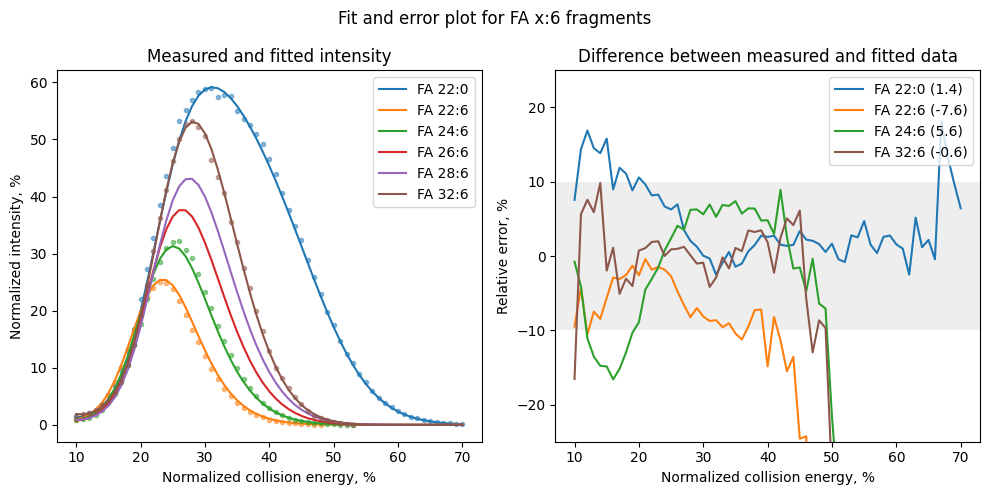

In [19]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 6, 4], [24, 6, 6], [26, 6, 8], [28, 6, 10], [32, 6, 14]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA x:6 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(test_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C_y == C) & (df.FA_DB_y == DB) & (df.FA_iso_y == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} ({round(av, 1)})', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')
    

plt.tight_layout()
plt.show()

### Saving/export of polynomial functions as eg pickle

In [20]:
# write polynomial coefficients and exponents to dictionary for export
poly_info = {'coeffs': sparse_poly_model.coeffs, 'exponents': sparse_poly_model.multi_index.exponents, 'lower_bounds': lower_bounds, 'upper_bounds': upper_bounds}

# Storing the polynomial object in a file
pickle.dump(poly_info, open(r'./polynomials/240905_PCO_sn2FA_poly.pkl', 'wb'))

In [21]:
poly_info

{'coeffs': array([-2.67338919e+01, -1.46016253e+01, -3.01364478e+00,  1.15416592e+01,
        -1.50784927e+00,  5.17965386e+00,  2.63574642e+00, -1.08195449e+00,
         3.34895663e+00,  7.77849350e-01,  2.33563471e+00, -4.96193130e+00,
        -1.28380081e+00,  3.30550393e-01, -1.72793462e+00,  9.01970273e-01,
        -2.30652122e-01,  2.10074021e-01,  6.24044277e-01,  4.16060292e-02,
         4.11198866e-02,  5.27575761e-11,  1.90430170e-02,  2.28510544e-11,
        -8.38726866e-11, -1.34095607e+01, -7.16773121e+00,  8.62826957e-01,
         5.22397279e+00,  4.77589267e-02,  3.09551418e+00,  3.18392845e-02,
         1.87595244e+00,  2.55887933e+00,  2.10645879e+00, -1.21789462e+00,
        -1.30215306e-02,  6.83952894e-12, -3.79756404e-01,  3.86002341e-12,
        -2.30652122e-01,  2.44069820e-01,  3.16235370e-01, -4.48925341e-11,
         2.85645258e-02, -4.57475169e-11,  1.90430172e-02, -1.14983578e-11,
        -3.24020810e-11, -5.68965790e+00, -3.56137676e+00,  1.30154734e+00,
  